In [64]:
import random 
import math

def gradient_descent_with_history(derivative, learning_rate, tolerance=1e-6, max_iters = 10000, x_init_range=(0,2)):
    x = random.uniform(*x_init_range)
    history = []

    for i in range(max_iters):
        slope = derivative(x)
        history.append(x)

        if abs(slope) < tolerance:
            return i, x, history, "converged"

        x = x - learning_rate * slope

    # divergemce detection
        if abs(x) > 1e6 or math.isnan(x) or math.isinf(x):
            return i, x, history, "diverged"

    return max_iters, x, history, "max_iters"


In [65]:
def test_learning_rates_with_history(derivative, learning_rates, x_init_range):
    results = []

    for lr in learning_rates:
        iters, x_final, history, status = gradient_descent_with_history(
            derivative,
            lr,
            x_init_range=x_init_range
        )

        results.append({
        "learning_rate": lr,
        "iterations": iters,
        "final_x": x_final,
        "history": history,
        "status": status
        })

    return results

In [66]:
import math

def d1(x): # (x + 5)^2
    return 2 * (x + 5)

def d2(x): # -(x - 1)^2 + 10 (no minimum!)
    return -2 * (x - 1)

def d3(x): # 2x^2 cos(x) - 5x
    return 4 * x * math.cos(x) - 2 *x * x * math.sin(x) - 5

def d4(x): # x^3 - 3x
    return 3 * x * x - 3

In [67]:
import matplotlib.pyplot as plt

def plot_lr_vs_iterations(results, title):
    lrs = []
    iters = []

    for r in results:
        if r["status"] == "converged":
            lrs.append(r["learning_rate"])
            iters.append(r["iterations"])

    plt.figure()
    plt.plot(lrs, iters, marker = 'o')
    plt.xscale("log")
    plt.xlabel("Learning Rate (log scale)")
    plt.ylabel("Iterations to converge")
    plt.title(title)
    plt.grid(True)
    plt.show()
    

In [68]:
def plot_trajectories(results, title):
    plt.figure()

    for r in results:
        print(r["learning_rate"], r["status"])
        if r["status"] == "converged":
            plt.plot(r["history"], label = f"lr = {r['learning_rate']}")
        else:
            plt.plot(r["history"], linestyle ='--', alpha = 0.04)

    plt.xlabel("Iterations")
    plt.ylabel("x value")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [69]:
learning_rates = [0.1, 0.05, 0.01, 0.005, 0.001]


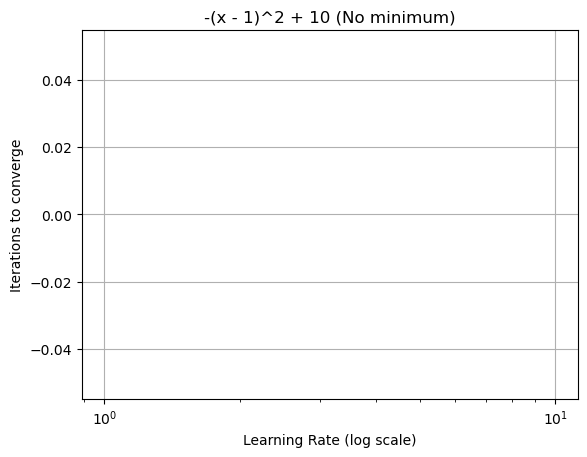

In [70]:
results = test_learning_rates_with_history(
    d2,
    learning_rates,
    x_init_range = (-5,5)
)

plot_lr_vs_iterations(results, "-(x - 1)^2 + 10 (No minimum)")

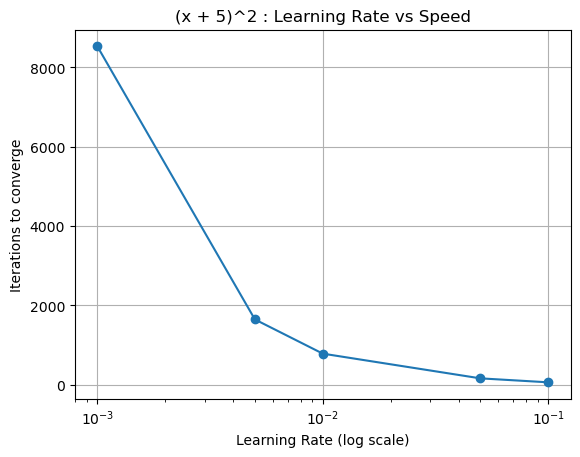

0.1 converged
0.05 converged
0.01 converged
0.005 converged
0.001 converged


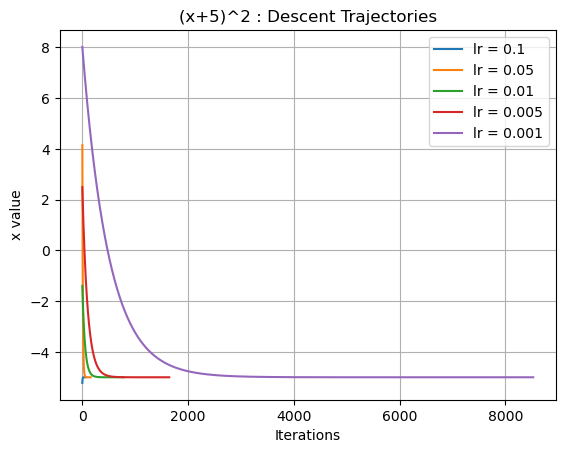

In [71]:

results = test_learning_rates_with_history(
    d1,
    learning_rates,
    x_init_range= (-10, 10)
)

plot_lr_vs_iterations(results, "(x + 5)^2 : Learning Rate vs Speed")
plot_trajectories(results, "(x+5)^2 : Descent Trajectories")


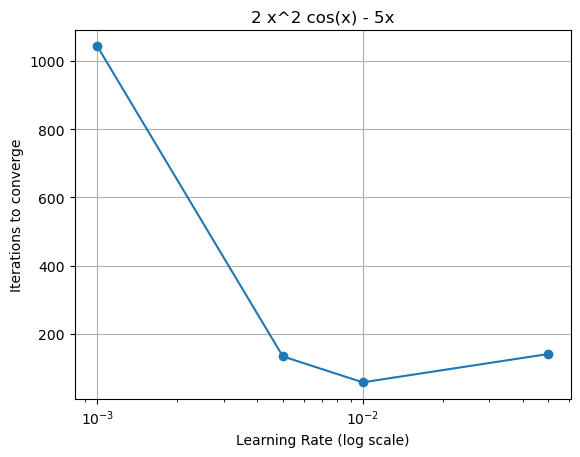

0.1 max_iters
0.05 converged
0.01 converged
0.005 converged
0.001 converged


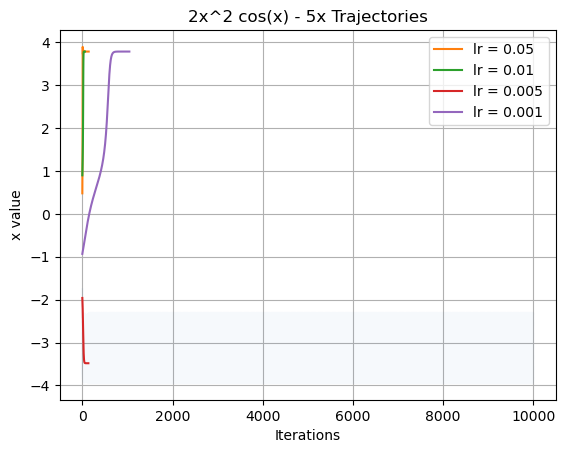

In [72]:
results = test_learning_rates_with_history(
    d3,
    learning_rates,
    x_init_range=(-2,2)
)

plot_lr_vs_iterations(results, "2 x^2 cos(x) - 5x")
plot_trajectories(results, "2x^2 cos(x) - 5x Trajectories")


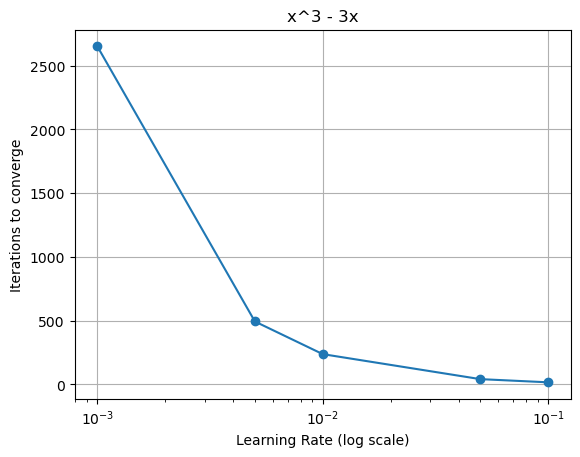

0.1 converged
0.05 converged
0.01 converged
0.005 converged
0.001 converged


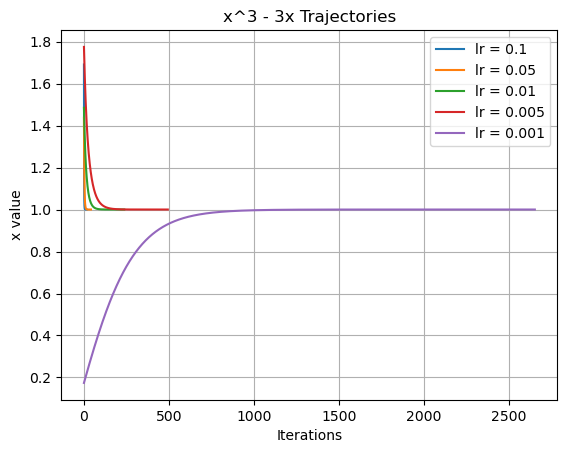

In [74]:
results = test_learning_rates_with_history(
    d4,
    learning_rates,
    x_init_range=(0,2)
)

plot_lr_vs_iterations(results, "x^3 - 3x")
plot_trajectories(results, "x^3 - 3x Trajectories")
